In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dataset = pd.read_csv("ByteTel Customer Interaction 2023.csv")

In [ ]:
dataset

,EmployeeID,Timestamp,NoteType,CustomerInteraction,EmployeeNote,FollowUpActionTaken,Outcome,AnonymizedID
0,E001,01-10-2023 09:45,Call Centre Agent,New Product Inquiry,Customer inquired about new broadband package.,Sent product details,Resolved,A1234
1,E002,01-10-2023 10:30,Engineer,Service Disruption,Checked customer's line. Cable damage identified.,Dispatched service team,Pending,A1235
2,E003,01-10-2023 11:15,Call Centre Agent,Billing Issue,Customer claims overcharge on recent bill.,Reviewed billing details,Resolved,A1236
3,E004,01-10-2023 12:05,Engineer,Service Disruption,Replaced damaged equipment at site.,Service restored,Resolved,A1237
4,E001,01-10-2023 13:40,Call Centre Agent,New Product Inquiry,Inquired about new TV packages and offers.,Sent promotional offers,Resolved,A1238
...,...,...,...,...,...,...,...,...
647,E616,08-12-2023 14:55,Field Agent,Device Installation,Installed a new security camera system at a cu...,Confirmed improved security,Resolved,A1881
648,E617,08-12-2023 15:45,Engineer,Service Disruption,Investigated reports of intermittent internet ...,Resolving connectivity issue,Pending,A1882
649,E618,08-12-2023 16:30,Billing Department,Billing Inquiry,Assisted a customer with a billing dispute rel...,Adjusted billing errors,Resolved,A1883
650,E619,08-12-2023 17:10,Call Centre Agent,Account Management,Helped a customer update their contact informa...,Confirmed updated contact info,Resolved,A1884


In [ ]:
dataset.isna().sum()

,0
EmployeeID,0
Timestamp,0
NoteType,0
CustomerInteraction,0
EmployeeNote,0
FollowUpActionTaken,0
Outcome,0
AnonymizedID,0


In [ ]:
dataset.duplicated().sum()

np.int64(0)

In [ ]:
X = dataset.iloc[:, 2:5]
y = dataset.iloc[:, 6]

In [ ]:
X

,NoteType,CustomerInteraction,EmployeeNote
0,Call Centre Agent,New Product Inquiry,Customer inquired about new broadband package.
1,Engineer,Service Disruption,Checked customer's line. Cable damage identified.
2,Call Centre Agent,Billing Issue,Customer claims overcharge on recent bill.
3,Engineer,Service Disruption,Replaced damaged equipment at site.
4,Call Centre Agent,New Product Inquiry,Inquired about new TV packages and offers.
...,...,...,...
647,Field Agent,Device Installation,Installed a new security camera system at a cu...
648,Engineer,Service Disruption,Investigated reports of intermittent internet ...
649,Billing Department,Billing Inquiry,Assisted a customer with a billing dispute rel...
650,Call Centre Agent,Account Management,Helped a customer update their contact informa...


In [ ]:
y

,Outcome
0,Resolved
1,Pending
2,Resolved
3,Resolved
4,Resolved
...,...
647,Resolved
648,Pending
649,Resolved
650,Resolved


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.25 , stratify=y,  random_state=0)

In [ ]:
X_train

,NoteType,CustomerInteraction,EmployeeNote
534,Call Centre Agent,Billing Inquiry,Customer needed details of their TV package su...
231,Chatbot Assistant,Service Complaint,Recorded an exhaustive complaint about intermi...
196,Chatbot Assistant,Service Complaint,Recorded a detailed complaint about intermitte...
228,Field Agent,Promotion Inquiry,Delivered an in-depth breakdown of discounted ...
227,Engineer,Device Setup Guidance,Provided an intricate step-by-step guide for c...
...,...,...,...
66,Field Agent,Promotion Inquiry,Checked eligibility for a free movie channel.
540,Engineer,Equipment Issue,Replaced a malfunctioning modem for a customer...
346,Chatbot Assistant,Service Complaint,Recorded an in-depth complaint about slow inte...
201,Chatbot Assistant,Service Complaint,Recorded an extensive complaint about intermit...


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
ct = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(ngram_range=(1,2), min_df=1, max_features=4000), "EmployeeNote"),
        ("cats", OneHotEncoder(handle_unknown="ignore"), ["CustomerInteraction","NoteType"]),
      ],
      remainder="drop",
      sparse_threshold=1.0

)

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)


In [ ]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14338 stored elements and shape (489, 1864)>

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test =  le.transform(y_test)


In [ ]:
y_bin = (y == "Pending").astype(int)   # 1 = Pending, 0 = Resolved


CustomerInteraction    0.366251
NoteType               0.197790
EmployeeNote           0.000000
dtype: float64


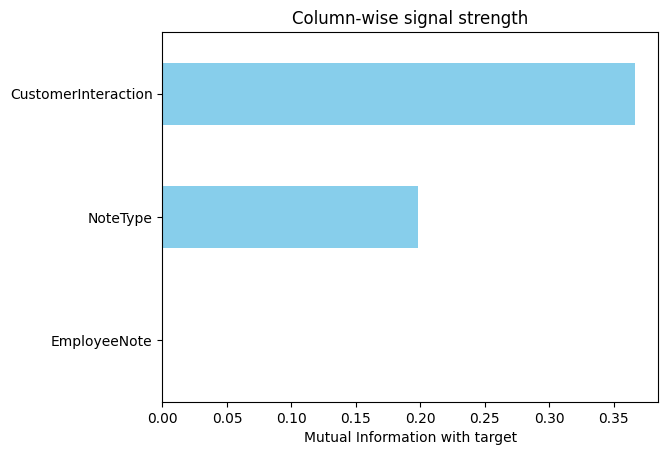

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y_bin = (y == "Pending").astype(int)  # 1 = Pending, 0 = Resolved

mi_scores = {}

for col in ["NoteType", "CustomerInteraction", "EmployeeNote"]:
    X_col = X[col]   # <-- use Series instead of DataFrame
    if col == "EmployeeNote":
        # For a quick check, mark only if note exists (1) or not (0)
        X_col = X_col.notnull().astype(int).values.reshape(-1, 1)
    else:
        # Convert categorical text labels to numeric codes
        X_col = X_col.astype("category").cat.codes.values.reshape(-1, 1)

    mi = mutual_info_classif(X_col, y_bin, discrete_features=True, random_state=42)
    mi_scores[col] = mi[0]

# Convert results to Series
mi_df = pd.Series(mi_scores).sort_values(ascending=False)
print(mi_df)

# Quick bar plot
mi_df.sort_values().plot(kind="barh", color="skyblue")
plt.xlabel("Mutual Information with target")
plt.title("Column-wise signal strength")
plt.show()


In [ ]:
y_train

array([1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier= LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[1 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
ac= accuracy_score(y_test, y_pred)
ac

0.9877300613496932

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

print("Confusion:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, classifier.predict_proba(X_test)[:,1]))
print("PR AUC:", average_precision_score(y_test, classifier.predict_proba(X_test)[:,1]))


Confusion:
 [[ 36   2]
 [  0 125]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97        38
           1       0.98      1.00      0.99       125

    accuracy                           0.99       163
   macro avg       0.99      0.97      0.98       163
weighted avg       0.99      0.99      0.99       163

ROC AUC: 0.987578947368421
PR AUC: 0.9957573138440344


**Phase** **2**

In [ ]:
dataset["note_len"] = dataset["EmployeeNote"].fillna("").str.split().str.len()
X_temp = dataset.copy()


In [ ]:
X_temp["Pending"] = (y == "Pending").astype(int)

X_temp["len_bucket"]= pd.qcut(X_temp["note_len"], q=4 , duplicates="drop")
pending_rate = X_temp.groupby("len_bucket")["Pending"].mean()
print(pending_rate)

len_bucket
(2.999, 7.0]     0.279070
(7.0, 9.0]       0.276699
(9.0, 19.0]      0.101695
(19.0, 110.0]    0.217949
Name: Pending, dtype: float64


/tmp/ipython-input-2162138375.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pending_rate = X_temp.groupby("len_bucket")["Pending"].mean()


In [ ]:
def note_length_risk(n_words, red_thr=20, yellow_thr=9):
    if n_words >= red_thr:
        return "RED"       # high risk
    elif n_words <= yellow_thr:
        return "YELLOW"    # moderate risk
    else:
        return "GREEN"     # low risk


In [ ]:
dataset["Risk_Level"] = dataset["note_len"].apply(note_length_risk)

In [ ]:
dataset

,EmployeeID,Timestamp,NoteType,CustomerInteraction,EmployeeNote,FollowUpActionTaken,Outcome,AnonymizedID,note_len,Risk_Level
0,E001,01-10-2023 09:45,Call Centre Agent,New Product Inquiry,Customer inquired about new broadband package.,Sent product details,Resolved,A1234,6,YELLOW
1,E002,01-10-2023 10:30,Engineer,Service Disruption,Checked customer's line. Cable damage identified.,Dispatched service team,Pending,A1235,6,YELLOW
2,E003,01-10-2023 11:15,Call Centre Agent,Billing Issue,Customer claims overcharge on recent bill.,Reviewed billing details,Resolved,A1236,6,YELLOW
3,E004,01-10-2023 12:05,Engineer,Service Disruption,Replaced damaged equipment at site.,Service restored,Resolved,A1237,5,YELLOW
4,E001,01-10-2023 13:40,Call Centre Agent,New Product Inquiry,Inquired about new TV packages and offers.,Sent promotional offers,Resolved,A1238,7,YELLOW
...,...,...,...,...,...,...,...,...,...,...
647,E616,08-12-2023 14:55,Field Agent,Device Installation,Installed a new security camera system at a cu...,Confirmed improved security,Resolved,A1881,10,GREEN
648,E617,08-12-2023 15:45,Engineer,Service Disruption,Investigated reports of intermittent internet ...,Resolving connectivity issue,Pending,A1882,6,YELLOW
649,E618,08-12-2023 16:30,Billing Department,Billing Inquiry,Assisted a customer with a billing dispute rel...,Adjusted billing errors,Resolved,A1883,12,GREEN
650,E619,08-12-2023 17:10,Call Centre Agent,Account Management,Helped a customer update their contact informa...,Confirmed updated contact info,Resolved,A1884,7,YELLOW
